In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import datetime
import cv2

import torch

DATA_PATH = "E:/ML/UBC"
print(DATA_PATH)


E:/ML/UBC


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [3]:
trainList = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
trainList.head()

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


In [4]:
from sklearn.preprocessing import LabelEncoder

uniqueLabels = trainList["label"].unique()

enc = LabelEncoder()
enc.fit(uniqueLabels)
print(enc.classes_)
enc.transform(["LGSC"])

['CC' 'EC' 'HGSC' 'LGSC' 'MC']


array([3])

In [5]:
allFiles = []
for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_thumbnails")):
    for f in files:
        if f.endswith(".png"):
            allFiles.append(os.path.join(root, f))
    
print(len(allFiles))

allFilesRe = []
for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images_rescaled")):
    for f in files:
        if f.endswith(".png"):
            allFilesRe.append(os.path.join(root, f))
    
len(allFilesRe)

513


538

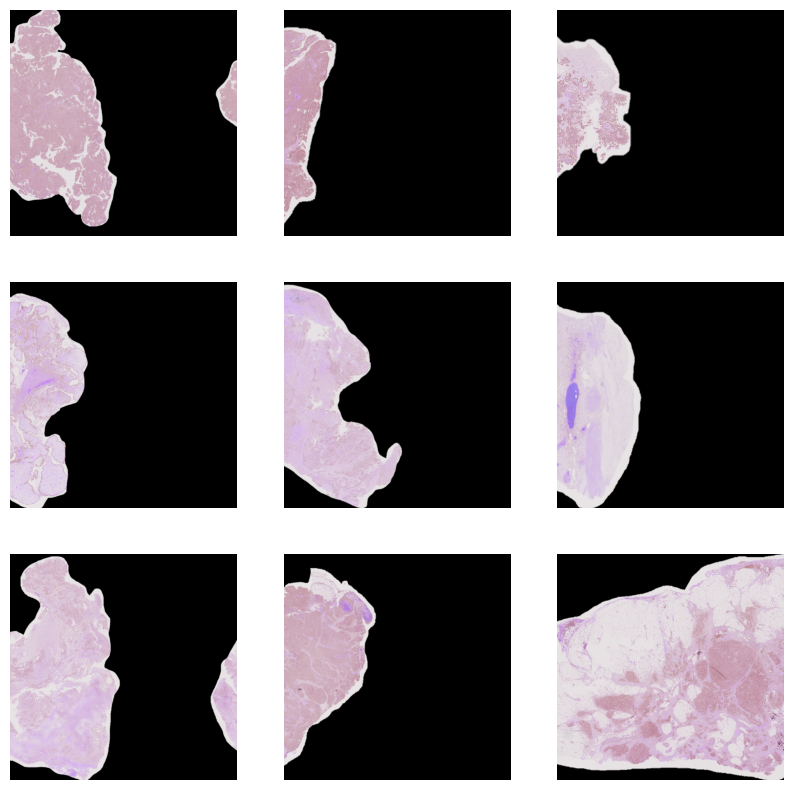

In [6]:

IMG_SIZE = (700, 700)
eps=1e-12

def readImage(path, skipResize=False):
    data = cv2.imread(path)
        
    w, h = data.shape[1], data.shape[0]
    # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
    # medValue = np.median(data)

    #Center crop
    if w>h:
        diff = w-h
        data = data[:, diff//4:diff//4+h]
    if h>w:
        diff = h-w
        data = data[diff//2:diff//2+w, :]

    # data = data - np.min(data)
    # data = data * 1.0/(np.max(data)+eps)

    w, h = data.shape[1], data.shape[0]

    # resize
    if not skipResize:
        if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
            data = np.array(cv2.resize(data, IMG_SIZE))
    
    # data = data/(np.max(data)+eps) * 2 - 1

    # data = (data * 255).astype(np.uint8)
    return data



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

In [7]:
allImages = {}
for i,filePath in enumerate(allFiles):
    im = readImage(filePath)
    id = filePath.split("\\")[-1].split(".")[0:-1][0].split("_")[0]
    allImages[id] = im



In [8]:

for tmaImId in trainList[trainList["is_tma"]==True]["image_id"].to_numpy():
    filePath = os.path.join(DATA_PATH, "train_images_rescaled", str(tmaImId)+".png")
    im = readImage(filePath)
    id = filePath.split("\\")[-1].split(".")[0:-1][0].split("_")[0]
    allImages[id] = im

In [9]:
TRAIN_TEST_SPLIT = 0.7

np.random.seed(56488)
# Make a deep copy such that the shuffling won't affect the patient id column in the dataset
# (skrews up the complete dataset)
trainListShuffle = trainList.copy(deep=True)
allIds = trainListShuffle["image_id"].to_numpy(copy=True)
split = int(allIds.shape[0]*TRAIN_TEST_SPLIT)
np.random.shuffle(allIds)
trainIds = allIds[0:split]
valIds = allIds[split::]

trainIds = trainListShuffle[trainListShuffle["is_tma"]==False]["image_id"].to_numpy()
valIds = trainListShuffle[trainListShuffle["is_tma"]==True]["image_id"].to_numpy()
print("# Training samples:",len(trainIds))
print("# Val samples:",len(valIds))

trainListIndexed= trainList.set_index("image_id")


def getData(id):
    arr = allImages[str(id)].astype(np.float32)/255.0
    # Arr3D = np.expand_dims(Arr3D, 0).astype(np.float32)

    targets = trainListIndexed.loc[id]
    label = np.array([targets["label"]])
    encLabel = enc.transform(label)
    # trueLabel = np.zeros(len(enc.classes_))
    # trueLabel[encLabel]=1
    return arr, encLabel.astype(np.int64)[0]


def generator():
    for trainId in trainIds:
        yield getData(trainId)


def generatorVal():
    for valId in valIds:
        yield getData(valId)

def generatorAll():
    for id in allIds:
        yield getData(id)

# Training samples: 513
# Training samples: 25


In [10]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)
testInstance[1]

2

In [11]:
BATCH_SIZE = 8

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainIds))
datasetVal = IterDataset(generatorVal, len(valIds))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
for X, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {X.shape} {X.dtype}")
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    # print(targets)
    break

Shape of X: torch.Size([8, 700, 700, 3]) torch.float32
Shape of target: torch.Size([8]) torch.int64


tensor(3)


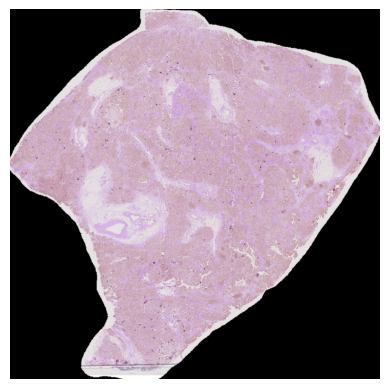

In [13]:
idx=1
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(X[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [14]:
from torch import nn
import torchinfo
from torch import nn
import torch
import timm

from modelZoo.models import Res2DModel, ResNet2DModel

Dropout=0.4
HIDDEN_DIM=128
K=1

    
# model = Res2DModel(len(enc.classes_), channels=3, name="Res2DModelPatches_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False)
model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
model.name = "resnet34d_thumbnails"

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [8, 5]                    --
├─Sequential: 1-1                        [8, 64, 350, 350]         --
│    └─Conv2d: 2-1                       [8, 32, 350, 350]         864
│    └─BatchNorm2d: 2-2                  [8, 32, 350, 350]         64
│    └─ReLU: 2-3                         [8, 32, 350, 350]         --
│    └─Conv2d: 2-4                       [8, 32, 350, 350]         9,216
│    └─BatchNorm2d: 2-5                  [8, 32, 350, 350]         64
│    └─ReLU: 2-6                         [8, 32, 350, 350]         --
│    └─Conv2d: 2-7                       [8, 64, 350, 350]         18,432
├─BatchNorm2d: 1-2                       [8, 64, 350, 350]         128
├─ReLU: 1-3                              [8, 64, 350, 350]         --
├─MaxPool2d: 1-4                         [8, 64, 175, 175]         --
├─Sequential: 1-5                        [8, 64, 175, 175]         --
│    └

In [15]:
# model_graph.visual_graph

In [16]:
loadExistingModel=False

if loadExistingModel:
    # model = simpleUnet(K=4)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), 5e-4)

    checkpoint = torch.load(os.path.join("./", "resnet34d_thumbnails_epoch_6_imsize_512.pt"), map_location=device)
    # startEpoch=136
    model.load_state_dict(checkpoint['model_state_dict'])
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    # startEpoch = checkpoint['epoch']
    startEpoch=0
    # loss = checkpoint['loss']
    model.train()
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), 5e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.998)

In [17]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import AUROC, Accuracy


LOG_INTERVAL=2
epochs = 50
EARLY_STOPPING_PATIENCE=3
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
lossFn = torch.nn.CrossEntropyLoss()


# accMetric = tf.keras.metrics.BinaryAccuracy()
accMetric = Accuracy(task="multiclass", num_classes=len(enc.classes_), average="micro").to(device)
aurocMetric = AUROC(task="multiclass", num_classes=len(enc.classes_)).to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

accMetricVal = Accuracy(task="multiclass", num_classes=len(enc.classes_), average=None).to(device)

# optimizer = torch.optim.SGD(model.parameters(), lr=0.004, momentum=0.9)

def train(dataloader, model, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (XTrain, yTrain) in enumerate(dataloader):
        XTrain = XTrain.movedim(-1,1)
        XTrain, yTrain = XTrain.to(device), yTrain.to(device)
        pred = model(XTrain)
        # targetLabel = torch.argmax(y, dim=1)
        
        loss = lossFn(pred, yTrain)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # scheduler.step()

        accMetric.update(pred, yTrain)
        aurocMetric.update(pred, yTrain)
        
        if batch % LOG_INTERVAL == 0:
            loss = loss.item()
            print("loss: {:>5f}, acc: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss, accMetric.compute(),  aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloader, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (XVal, yVal) in enumerate(dataloader):
        XVal = XVal.movedim(-1,1)
        XVal, yVal = XVal.to(device), yVal.to(device)
        predVal = model(XVal)
        # targetLabel = torch.argmax(y, dim=1)
        lossAdd = lossFn(predVal, yVal)
        loss += lossAdd.detach().cpu().numpy()
        accMetricVal.update(predVal, yVal)
        
    lossVal = loss.item()/(batch+1)
    print("Weighted Avg Cross Entropy: {:>7f}".format(lossVal))
    print("Accuracy: {:>7f}".format(torch.mean(accMetricVal.compute())))
    summary_writer.add_scalar("Val BCE", lossVal, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.flush()
    fig, ax = accMetricVal.plot()
    fig.savefig(os.path.join(DATA_PATH, "metricPlots", "accuracy_{}.png".format(epoch)))
    plt.close()
    return torch.mean(accMetricVal.compute())


bestValAcc=0.0
bestEpoch=0

for t in np.arange(startEpoch, startEpoch+epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    aurocMetric.reset()

    avgAccVal = validate(valLoader, model, t)
    accMetricVal.reset()

    if saveModel:
        model_scripted = torch.jit.script(model) # Export to TorchScript
        fileName = "{}_epoch{}_CE{:.4f}.pt".format(model.name, t, avgAccVal)
        model_scripted.save(os.path.join(DATA_PATH, fileName))
    
    #Early stopping
    if avgAccVal > bestValAcc:
        bestValAcc = avgAccVal
        bestEpoch = t
        bestWeights = model.state_dict()
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

    print("LR: {:.2E}".format(optimizer.state_dict()["param_groups"][0]["lr"]))
    
print("Done!")

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchaudio\backend\utils.py:74: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


Epoch 1
-------------------------------


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 1.752393, acc: 0.1250, AUROC: 0.3262  [    0/  513]
loss: 1.536071, acc: 0.3750, AUROC: 0.3747  [   16/  513]
loss: 1.641360, acc: 0.3500, AUROC: 0.3886  [   32/  513]
loss: 1.309548, acc: 0.4464, AUROC: 0.5026  [   48/  513]
loss: 1.364230, acc: 0.4028, AUROC: 0.5351  [   64/  513]
loss: 1.118670, acc: 0.4205, AUROC: 0.5748  [   80/  513]
loss: 1.912866, acc: 0.4135, AUROC: 0.5750  [   96/  513]
loss: 1.320315, acc: 0.4167, AUROC: 0.5942  [  112/  513]
loss: 1.394977, acc: 0.4191, AUROC: 0.5876  [  128/  513]
loss: 1.042638, acc: 0.4276, AUROC: 0.6169  [  144/  513]
loss: 0.885381, acc: 0.4464, AUROC: 0.6296  [  160/  513]
loss: 1.452106, acc: 0.4402, AUROC: 0.6348  [  176/  513]
loss: 1.598258, acc: 0.4250, AUROC: 0.6293  [  192/  513]
loss: 0.827268, acc: 0.4537, AUROC: 0.6486  [  208/  513]
loss: 1.343904, acc: 0.4569, AUROC: 0.6426  [  224/  513]
loss: 1.309936, acc: 0.4637, AUROC: 0.6421  [  240/  513]
loss: 1.238026, acc: 0.4583, AUROC: 0.6362  [  256/  513]
loss: 1.093462

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


...

loss: 1.338897, acc: 0.3750, AUROC: 0.4533  [    0/  513]
loss: 1.315484, acc: 0.4583, AUROC: 0.7809  [   16/  513]
loss: 0.962466, acc: 0.5250, AUROC: 0.8402  [   32/  513]
loss: 1.050043, acc: 0.5714, AUROC: 0.8027  [   48/  513]
loss: 1.294652, acc: 0.5417, AUROC: 0.8011  [   64/  513]
loss: 0.704021, acc: 0.5682, AUROC: 0.8250  [   80/  513]
loss: 1.217452, acc: 0.5577, AUROC: 0.8287  [   96/  513]
loss: 1.925634, acc: 0.5417, AUROC: 0.8048  [  112/  513]
loss: 1.211705, acc: 0.5588, AUROC: 0.8021  [  128/  513]
loss: 0.783433, acc: 0.5855, AUROC: 0.8070  [  144/  513]
loss: 0.709663, acc: 0.5952, AUROC: 0.8099  [  160/  513]
loss: 1.208769, acc: 0.5761, AUROC: 0.8096  [  176/  513]
loss: 0.938996, acc: 0.5700, AUROC: 0.8152  [  192/  513]
loss: 0.739623, acc: 0.5787, AUROC: 0.8119  [  208/  513]
loss: 1.461070, acc: 0.5862, AUROC: 0.8020  [  224/  513]
loss: 1.440360, acc: 0.5887, AUROC: 0.7957  [  240/  513]
loss: 1.113318, acc: 0.5871, AUROC: 0.7948  [  256/  513]
loss: 0.542667

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 1.132103, acc: 0.5000, AUROC: 0.4900  [    0/  513]
loss: 1.000941, acc: 0.5833, AUROC: 0.8821  [   16/  513]
loss: 0.773126, acc: 0.6750, AUROC: 0.9186  [   32/  513]
loss: 0.816110, acc: 0.7143, AUROC: 0.9167  [   48/  513]
loss: 1.053248, acc: 0.6944, AUROC: 0.9054  [   64/  513]
loss: 0.347477, acc: 0.7159, AUROC: 0.9165  [   80/  513]
loss: 1.046099, acc: 0.7019, AUROC: 0.9170  [   96/  513]
loss: 1.520970, acc: 0.6833, AUROC: 0.9067  [  112/  513]
loss: 1.083867, acc: 0.6838, AUROC: 0.8987  [  128/  513]
loss: 0.681006, acc: 0.7039, AUROC: 0.8997  [  144/  513]
loss: 0.643000, acc: 0.7083, AUROC: 0.9010  [  160/  513]
loss: 1.334580, acc: 0.6957, AUROC: 0.8992  [  176/  513]
loss: 0.810846, acc: 0.6900, AUROC: 0.8973  [  192/  513]
loss: 0.423686, acc: 0.7037, AUROC: 0.8927  [  208/  513]
loss: 0.868464, acc: 0.6983, AUROC: 0.8862  [  224/  513]
loss: 1.048845, acc: 0.6895, AUROC: 0.8815  [  240/  513]
loss: 0.927883, acc: 0.6856, AUROC: 0.8807  [  256/  513]
loss: 0.705937

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 1.352288, acc: 0.3750, AUROC: 0.4467  [    0/  513]
loss: 0.870987, acc: 0.5000, AUROC: 0.8641  [   16/  513]
loss: 0.798957, acc: 0.6250, AUROC: 0.9015  [   32/  513]
loss: 0.909640, acc: 0.6786, AUROC: 0.8996  [   48/  513]
loss: 0.674155, acc: 0.7083, AUROC: 0.9065  [   64/  513]
loss: 0.413177, acc: 0.7159, AUROC: 0.9194  [   80/  513]
loss: 1.243425, acc: 0.7308, AUROC: 0.9171  [   96/  513]
loss: 0.980520, acc: 0.7250, AUROC: 0.9121  [  112/  513]
loss: 0.807261, acc: 0.7206, AUROC: 0.9116  [  128/  513]
loss: 0.472845, acc: 0.7303, AUROC: 0.9157  [  144/  513]
loss: 0.524479, acc: 0.7440, AUROC: 0.9210  [  160/  513]
loss: 1.314806, acc: 0.7283, AUROC: 0.9171  [  176/  513]
loss: 0.356084, acc: 0.7300, AUROC: 0.9202  [  192/  513]
loss: 0.490635, acc: 0.7222, AUROC: 0.9133  [  208/  513]
loss: 0.576481, acc: 0.7241, AUROC: 0.9119  [  224/  513]
loss: 1.000433, acc: 0.7137, AUROC: 0.9092  [  240/  513]
loss: 0.644672, acc: 0.7121, AUROC: 0.9134  [  256/  513]
loss: 0.503839

In [18]:
model.load_state_dict(bestWeights)

<All keys matched successfully>

In [18]:
bestValAcc

tensor(0.2400, device='cuda:0')

In [20]:
torch.save({
    'epoch': t,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    # 'loss': loss,
    }, os.path.join("./", model.name+f"_epoch_{t}_imsize_{IMG_SIZE[0]}.pt"))

In [20]:
# torch.save(model.state_dict, os.path.join(DATA_PATH, "convModel.pt"))

# model_scripted = torch.jit.script(model) # Export to TorchScript
# model_scripted.save('model_scripted.pt') # Save